In [1]:
import rhkpy
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import holoviews as hv
import gwyfile
import scienceplots # matplotlib styles

In [ ]:
# Download data files from Zenodo if not cached locally
import os
import urllib.request

ZENODO_BASE = "https://zenodo.org/records/19680005/files"
DATA_DIR = "data"

def fetch_zenodo(filename):
    os.makedirs(DATA_DIR, exist_ok=True)
    local_path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(local_path):
        url = f"{ZENODO_BASE}/{filename}?download=1"
        print(f"Downloading {filename} from Zenodo...")
        urllib.request.urlretrieve(url, local_path)
    return local_path

In [2]:
print(rhkpy.__version__)
print(gwyfile.__version__)
print(hv.__version__)
print(np.__version__)
print(matplotlib.__version__)

1.3.9
0.3.0
1.21.0
2.3.1
3.10.3


In [3]:
# Basic options for plotting figure for the paper
plt.style.use(['science', 'no-latex', 'nature', 'std-colors'])
matplotlib.rcParams['pdf.fonttype'] = 42 # use type 2 fonts
matplotlib.rcParams['ps.fonttype'] = 42 # use type 2 fonts
plt.rcParams['svg.fonttype'] = 'none'  # makes editable fonts in inkscape

In [ ]:
# Metadata
stm326 = rhkpy.rhkdata(fetch_zenodo("ZrTe5K7_9K_2019_10_10_12_18_06_326.sm4"))
stm905 = rhkpy.rhkdata(fetch_zenodo("ZrTe5_K7_300K_2019_11_06_17_28_03_905.sm4"))

In [5]:
stm326.image.attrs

{'filename': 'ZrTe5K7_9K_2019_10_10_12_18_06_326.sm4',
 'xoffset': np.float64(183.4397848343716),
 'yoffset': np.float64(257.64895342228476),
 'xoffset_units': 'nm',
 'yoffset_units': 'nm',
 'size_x': np.float64(200.0),
 'size_y': np.float64(200.0),
 'size_x units': 'nm',
 'size_y units': 'nm',
 'bias': np.float32(0.49999988),
 'bias units': 'V',
 'setpoint': np.float32(499.99997),
 'setpoint units': 'pA',
 'measurement date': '10/10/19',
 'measurement time': '11:43:53',
 'scan angle': np.float32(0.0),
 'datatype': 'image',
 'spectype': None}

In [6]:
stm905.image.attrs

{'filename': 'ZrTe5_K7_300K_2019_11_06_17_28_03_905.sm4',
 'xoffset': np.float64(-1361.3857919869688),
 'yoffset': np.float64(246.12454974093367),
 'xoffset_units': 'nm',
 'yoffset_units': 'nm',
 'size_x': np.float64(1000.0),
 'size_y': np.float64(1000.0),
 'size_x units': 'nm',
 'size_y units': 'nm',
 'bias': np.float32(0.5),
 'bias units': 'V',
 'setpoint': np.float32(49.999996),
 'setpoint units': 'pA',
 'measurement date': '11/06/19',
 'measurement time': '15:34:05',
 'scan angle': np.float32(0.0),
 'datatype': 'image',
 'spectype': None}

In [ ]:
gwy_obj = gwyfile.load(fetch_zenodo("ZrTe5_K7_300K_2019_11_06_17_28_03_905.gwy"))
channels905 = gwyfile.util.get_datafields(gwy_obj)

In [ ]:
gwy_obj = gwyfile.load(fetch_zenodo("ZrTe5K7_9K_2019_10_10_12_18_06_326.gwy"))
channels326 = gwyfile.util.get_datafields(gwy_obj)

In [9]:
channels326.keys()

dict_keys(['LIA Current [Left]', 'LIA Current [Right]', 'Current [Left]', 'Current [Right]', 'Topography [Left]', 'Topography [Right]'])

In [12]:
hv.extension('matplotlib')

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W

In [13]:
def gwy_to_hv_image(channel, label):
    data = channel.data * 1e9
    xoff = channel.xoff * 1e9
    yoff = channel.yoff * 1e9
    xreal = channel.xreal * 1e9
    yreal = channel.yreal * 1e9
    bounds = (xoff, yoff, xoff + xreal, yoff + yreal)
    return hv.Image(data, bounds=bounds, label=label).opts(
        cmap='inferno', clim=(0, 2),
        xaxis=None, yaxis=None,
        colorbar=True, clabel='height (nm)',
        fig_size=80,
        title="",
        colorbar_opts={'extendfrac': 0},
        fontsize={'title': 12, 'labels': 10, 'xticks': 8, 'yticks': 8, 'clabel': 8, 'cticks': 8}
    )

img905 = gwy_to_hv_image(channels905['Detail 6'], '905')
img326 = gwy_to_hv_image(channels326['Topography [Left]'], '326')

:Image   [x,y]   (z)
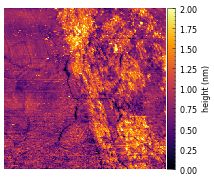

In [14]:
img905

:Image   [x,y]   (z)
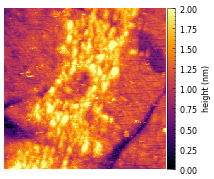

In [15]:
img326

In [16]:
hv.save(img326, 'STM_9K_326.svg')
hv.save(img905, 'STM_300K_905.svg')